In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,accuracy_score, precision_score, recall_score, f1_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import optuna
import joblib

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
for i in df.columns:
    print('*'*50)
    print(i)
    print(df[i].unique())

**************************************************
customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
**************************************************
gender
['Female' 'Male']
**************************************************
SeniorCitizen
[0 1]
**************************************************
Partner
['Yes' 'No']
**************************************************
Dependents
['No' 'Yes']
**************************************************
tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
**************************************************
PhoneService
['No' 'Yes']
**************************************************
MultipleLines
['No phone service' 'No' 'Yes']
**************************************************
InternetService
['DSL' 'Fiber optic' 'No']
*********

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
churn_counts = df['Churn'].value_counts()

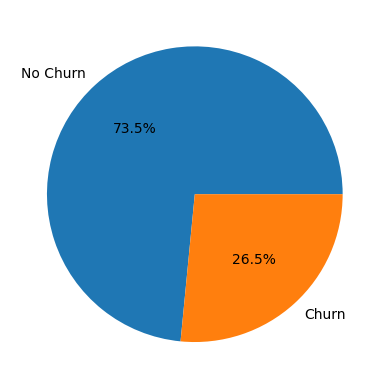

In [10]:
plt.pie(churn_counts, autopct='%1.1f%%', labels=['No Churn', 'Churn'])
plt.show()

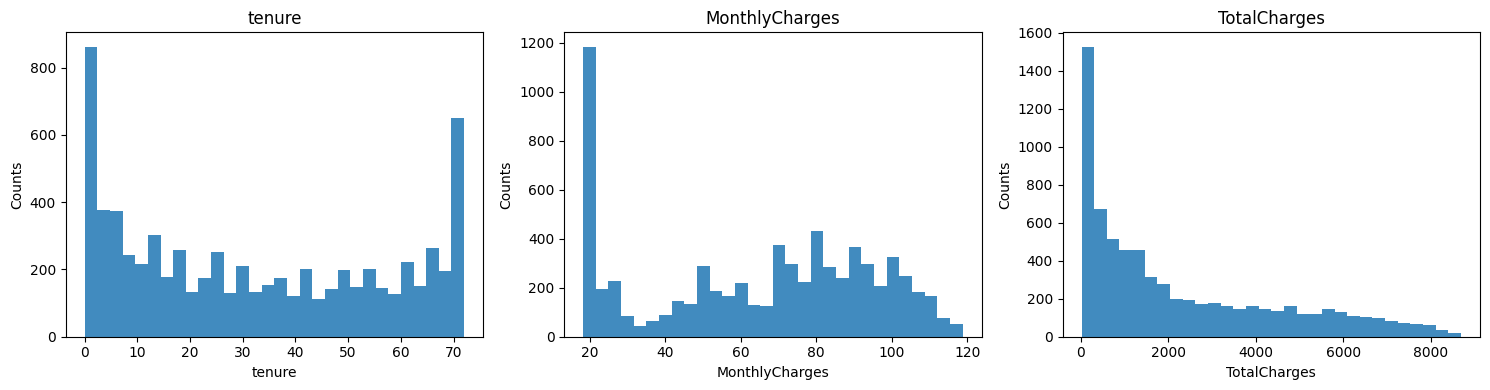

In [11]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

for i, cols in enumerate(num_cols):
    ax[i].hist(df[cols].dropna(), bins=30, alpha=0.85)
    ax[i].set_title(cols)
    ax[i].set_xlabel(cols)
    ax[i].set_ylabel('Counts')

plt.tight_layout()
plt.show()

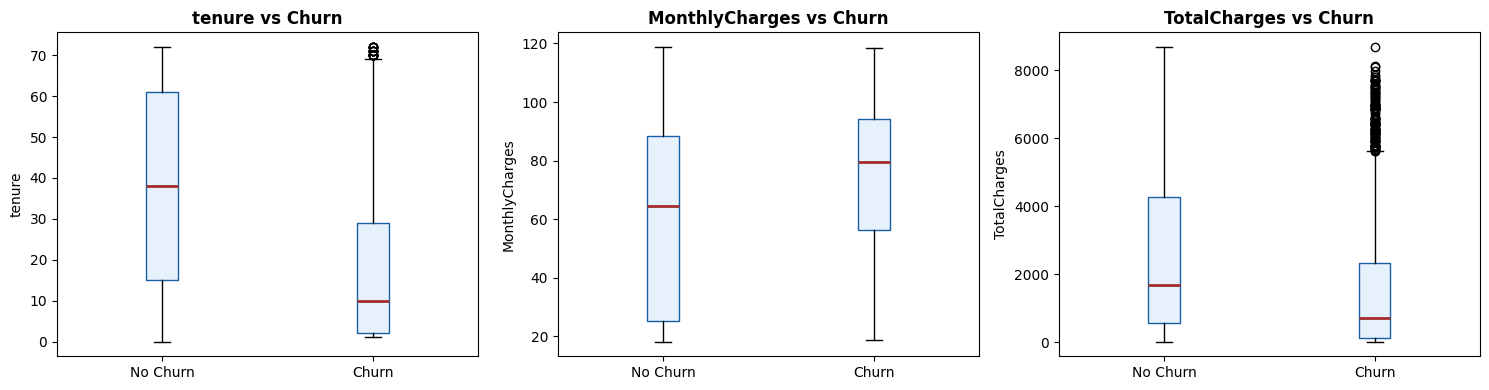

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
for i, col in enumerate(num_cols):
    churn_yes = df[df['Churn'] == 'Yes'][col].dropna()
    churn_no  = df[df['Churn'] == 'No'][col].dropna()
    axes[i].boxplot([churn_no, churn_yes], labels=['No Churn', 'Churn'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#E6F1FB', color='#185FA5'),
                    medianprops=dict(color='#A32D2D', linewidth=2))
    axes[i].set_title(f'{col} vs Churn', fontweight='bold')
    axes[i].set_ylabel(col)
 
plt.tight_layout()
plt.show()

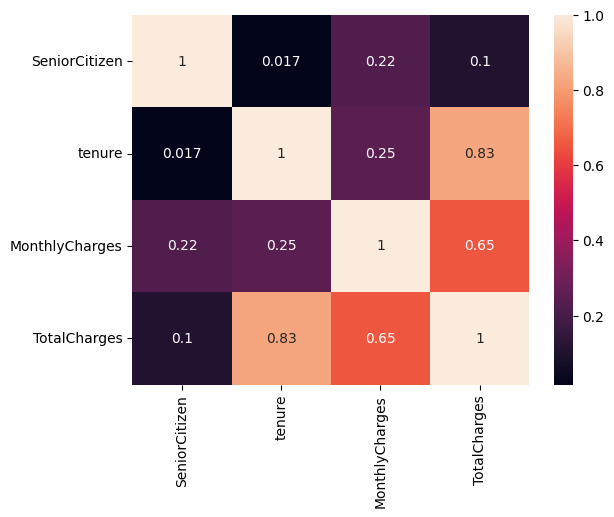

In [13]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [14]:
df.drop(columns=['customerID'], inplace=True)

In [15]:
def tenure_group(tenure):
    if tenure <=12:
        return 'New'
    elif tenure<=24:
        return 'Developing'
    elif tenure<=48:
        return 'Estabilished'
    else:
        return 'loyal'

In [16]:
df['tenure_group']=df['tenure'].apply(tenure_group)

In [17]:
df['ChargePerMonth'] = (df['TotalCharges'] / (df['tenure'] + 1)).round(2)

In [18]:
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']

In [19]:
df['service_count'] = df[service_cols].apply(
    lambda row:sum(1 for val in row if val =='Yes'), axis=1
)

In [20]:
df['HasPremiumServices'] = (
    (df['OnlineSecurity'] == 'Yes') |
    (df['TechSupport'] == 'Yes') |
    (df['DeviceProtection'] == 'Yes')
).astype(int)

In [22]:
median_charge = df['MonthlyCharges'].median()
print(median_charge)

70.35


In [23]:
df['IsHighValue'] = (df['MonthlyCharges'] > median_charge).astype(int)

In [24]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,ChargePerMonth,service_count,HasPremiumServices,IsHighValue
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Yes,Electronic check,29.85,29.85,No,New,14.92,1,0,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,Mailed check,56.95,1889.50,No,Estabilished,53.99,3,1,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Yes,Mailed check,53.85,108.15,Yes,New,36.05,3,1,0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,Bank transfer (automatic),42.30,1840.75,No,Estabilished,40.02,3,1,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Yes,Electronic check,70.70,151.65,Yes,New,50.55,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Mailed check,84.80,1990.50,No,Developing,79.62,7,1,1
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,Yes,Credit card (automatic),103.20,7362.90,No,loyal,100.86,6,1,1
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,Yes,Electronic check,29.60,346.45,No,New,28.87,1,1,0
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,Yes,Mailed check,74.40,306.60,Yes,New,61.32,2,0,1


In [25]:
df['TotalCharges'].fillna(df['MonthlyCharges'], inplace=True)

In [26]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

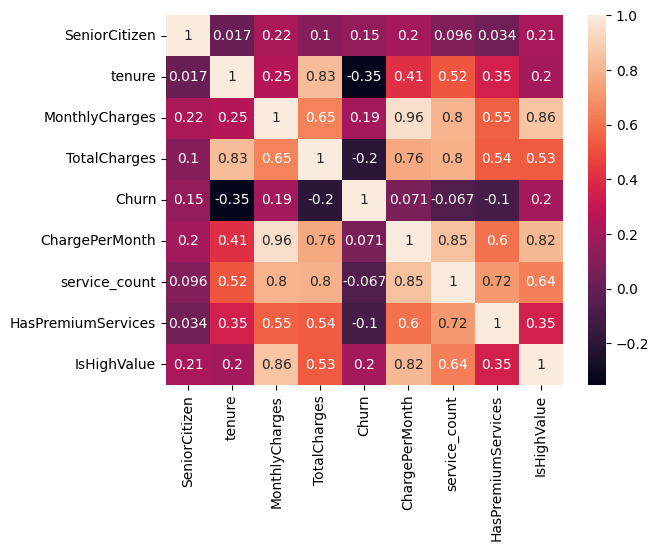

In [27]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              7043 non-null   object 
 1   SeniorCitizen       7043 non-null   int64  
 2   Partner             7043 non-null   object 
 3   Dependents          7043 non-null   object 
 4   tenure              7043 non-null   int64  
 5   PhoneService        7043 non-null   object 
 6   MultipleLines       7043 non-null   object 
 7   InternetService     7043 non-null   object 
 8   OnlineSecurity      7043 non-null   object 
 9   OnlineBackup        7043 non-null   object 
 10  DeviceProtection    7043 non-null   object 
 11  TechSupport         7043 non-null   object 
 12  StreamingTV         7043 non-null   object 
 13  StreamingMovies     7043 non-null   object 
 14  Contract            7043 non-null   object 
 15  PaperlessBilling    7043 non-null   object 
 16  Paymen

In [26]:
numeric_cols = ['tenure', 'MonthlyCharges','TotalCharges','ChargePerMonth',
               'service_count','HasPremiumServices', 'IsHighValue']
categorical_cols = [
    'gender', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod',
    'tenure_group'
]

In [27]:
X = df[numeric_cols + categorical_cols]
y = df['Churn']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [29]:
numeric_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ('scaler', StandardScaler())
    ]
)
categorical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ]
)

In [31]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200,learning_rate=0.1,random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42,eval_metric="logloss",n_estimators=200)
}

In [32]:
results = []

for name, model in models.items():
    print('='*60)
    print(f'Model: {name}')
    print('='*60)

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    if hasattr(pipeline, "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = None

    results.append({
        "Model": name,
        "ROC AUC": roc_auc
    })

    print(f"ROC AUC Score: {roc_auc:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\n")


Model: Logistic Regression
ROC AUC Score: 0.8452

Confusion Matrix:
[[938  97]
 [177 197]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



Model: KNN
ROC AUC Score: 0.7799

Confusion Matrix:
[[879 156]
 [182 192]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1035
           1       0.55      0.51      0.53       374

    accuracy                           0.76      1409
   macro avg       0.69      0.68      0.69      1409
weighted avg       0.76      0.76      0.76      1409



Model: Decision Tree
ROC AUC Score: 0.6704

Confusion Matrix:
[[849 186]
 [179 195]]

Classification Report:
              preci

In [33]:
results = []

for name, model in models.items():

    print("=" * 60)
    print(f"Model: {name}")
    print("=" * 60)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    y_prob = pipeline.predict_proba(X_test)[:,1]

    print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\n")

Model: Logistic Regression
ROC AUC Score: 0.8427

Confusion Matrix:
[[745 290]
 [ 77 297]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



Model: KNN
ROC AUC Score: 0.7636

Confusion Matrix:
[[693 342]
 [ 98 276]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.67      0.76      1035
           1       0.45      0.74      0.56       374

    accuracy                           0.69      1409
   macro avg       0.66      0.70      0.66      1409
weighted avg       0.76      0.69      0.71      1409



Model: Decision Tree
ROC AUC Score: 0.6688

Confusion Matrix:
[[808 227]
 [166 208]]

Classification Report:
              preci

In [34]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [35]:
def objective(trial):
    params = {
        'C': trial.suggest_float('C',1e-4,100,log=True),
        'solver': trial.suggest_categorical('solver',['liblinear', 'lbfgs']),
        'max_iter':1000,
        'random_state':42
    }

    model = LogisticRegression(**params)

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    score = cross_val_score(pipeline,X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)

    return score.mean()

In [36]:
study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective, n_trials=30, show_progress_bar=True)

[I 2026-07-08 21:10:07,364] A new study created in memory with name: no-name-07f7926f-5dcd-4077-88a4-7816d7c4787e


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-07-08 21:10:13,732] Trial 0 finished with value: 0.6303733930170023 and parameters: {'C': 0.027073144259874057, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.6303733930170023.
[I 2026-07-08 21:10:14,538] Trial 1 finished with value: 0.633921585408614 and parameters: {'C': 0.4434546907088912, 'solver': 'liblinear'}. Best is trial 1 with value: 0.633921585408614.
[I 2026-07-08 21:10:15,488] Trial 2 finished with value: 0.6328829970222845 and parameters: {'C': 1.009132951082691, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.633921585408614.
[I 2026-07-08 21:10:16,283] Trial 3 finished with value: 0.6323605344098279 and parameters: {'C': 1.5374323767716758, 'solver': 'liblinear'}. Best is trial 1 with value: 0.633921585408614.
[I 2026-07-08 21:10:16,879] Trial 4 finished with value: 0.6214431637640193 and parameters: {'C': 0.00014417015309552855, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.633921585408614.
[I 2026-07-08 21:10:17,619] Trial 5 finished with value: 0.626

In [37]:
print("="*60)
print("Best CV F1 Score")
print(study_lr.best_value)
print()
print("Best Parameters")
print(study_lr.best_params)

Best CV F1 Score
0.6355598576741076

Best Parameters
{'C': 0.013923267957130366, 'solver': 'liblinear'}


In [38]:
best_model = LogisticRegression(**study_lr.best_params,random_state=42,max_iter=1000)

pipeline_LR = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", best_model)
])

pipeline_LR.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](23,)","['tenure','MonthlyCharges','TotalCharges',...,'PaperlessBilling', 'PaymentMethod','tenure_group']"
n_features_in_,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [39]:
y_pred_LR = pipeline_LR.predict(X_test)
y_prob_LR = pipeline_LR.predict_proba(X_test)[:,1]

In [40]:
print("="*60)
print("Logistic Regression After Optuna")
print("="*60)

print(f"ROC AUC Score : {roc_auc_score(y_test,y_prob):.4f}")

print()

print("Confusion Matrix")

print(confusion_matrix(y_test,y_pred))

print()

print("Classification Report")

print(classification_report(y_test,y_pred))

Logistic Regression After Optuna
ROC AUC Score : 0.8143

Confusion Matrix
[[881 154]
 [166 208]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1035
           1       0.57      0.56      0.57       374

    accuracy                           0.77      1409
   macro avg       0.71      0.70      0.71      1409
weighted avg       0.77      0.77      0.77      1409



In [41]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators",100,500),
        "max_depth": trial.suggest_int("max_depth",5,30),
        "min_samples_split": trial.suggest_int("min_samples_split",2,20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf",1,10),
        "max_features": trial.suggest_categorical("max_features",["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap",[True, False]),
        "criterion": trial.suggest_categorical("criterion",["gini", "entropy"]),
        "random_state":42,
        "n_jobs":-1
    }

    model = RandomForestClassifier(**params)

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    score = cross_val_score(pipeline,X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)

    return score.mean()

In [42]:
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective, n_trials=50, show_progress_bar=True)

[I 2026-07-08 21:10:35,980] A new study created in memory with name: no-name-aacebedb-144e-4bdb-b83c-7954a7da7455


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-08 21:12:34,753] Trial 0 finished with value: 0.5437711421773553 and parameters: {'n_estimators': 331, 'max_depth': 25, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': None, 'bootstrap': False, 'criterion': 'gini'}. Best is trial 0 with value: 0.5437711421773553.
[I 2026-07-08 21:13:01,509] Trial 1 finished with value: 0.6287361073652618 and parameters: {'n_estimators': 443, 'max_depth': 18, 'min_samples_split': 18, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': True, 'criterion': 'entropy'}. Best is trial 1 with value: 0.6287361073652618.
[I 2026-07-08 21:13:22,428] Trial 2 finished with value: 0.6279939105562324 and parameters: {'n_estimators': 344, 'max_depth': 23, 'min_samples_split': 16, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 1 with value: 0.6287361073652618.
[I 2026-07-08 21:14:31,700] Trial 3 finished with value: 0.5907976782578511 and parameters: {'n_estimators': 257, 'max_dept

In [43]:
print("="*60)
print("Best CV F1 Score")
print(study_rf.best_value)

print()

print("Best Parameters")
print(study_rf.best_params)

Best CV F1 Score
0.6369491889749955

Best Parameters
{'n_estimators': 478, 'max_depth': 8, 'min_samples_split': 6, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'entropy'}


In [44]:
best_model = RandomForestClassifier(**study_rf.best_params,random_state=42)

pipeline_RF = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", best_model)
])

pipeline_RF.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](23,)","['tenure','MonthlyCharges','TotalCharges',...,'PaperlessBilling', 'PaymentMethod','tenure_group']"
n_features_in_,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [45]:
y_pred_RF = pipeline_RF.predict(X_test)
y_prob_RF = pipeline_RF.predict_proba(X_test)[:,1]

In [46]:
print("="*60)
print("Random Forest After Optuna")
print("="*60)

print(f"ROC AUC Score : {roc_auc_score(y_test,y_prob):.4f}")

print()

print("Confusion Matrix")

print(confusion_matrix(y_test,y_pred))

print()

print("Classification Report")

print(classification_report(y_test,y_pred))

Random Forest After Optuna
ROC AUC Score : 0.8143

Confusion Matrix
[[881 154]
 [166 208]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1035
           1       0.57      0.56      0.57       374

    accuracy                           0.77      1409
   macro avg       0.71      0.70      0.71      1409
weighted avg       0.77      0.77      0.77      1409



In [47]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators",50,500),
        "learning_rate": trial.suggest_float("learning_rate",0.01,0.3,log=True),
        "max_depth": trial.suggest_int("max_depth",2,8),
        "min_samples_split": trial.suggest_int("min_samples_split",2,20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf",1,10),
        "subsample": trial.suggest_float("subsample",0.6,1.0),
        "max_features": trial.suggest_categorical("max_features",["sqrt", "log2", None]),
        "random_state":42
    }

    model = GradientBoostingClassifier(**params)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    score = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    return score.mean()

In [48]:
study_gb = optuna.create_study(direction="maximize")
study_gb.optimize(objective,n_trials=50,show_progress_bar=True)

[I 2026-07-08 21:44:28,299] A new study created in memory with name: no-name-7dad4a81-ceec-4648-ac31-401c2e30ee79


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-08 21:46:31,039] Trial 0 finished with value: 0.5830064666514874 and parameters: {'n_estimators': 407, 'learning_rate': 0.05986882622616035, 'max_depth': 7, 'min_samples_split': 3, 'min_samples_leaf': 4, 'subsample': 0.9104449546051363, 'max_features': None}. Best is trial 0 with value: 0.5830064666514874.
[I 2026-07-08 21:46:48,131] Trial 1 finished with value: 0.6370358592541795 and parameters: {'n_estimators': 442, 'learning_rate': 0.01835254090118622, 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 1, 'subsample': 0.909454478634368, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.6370358592541795.
[I 2026-07-08 21:46:52,349] Trial 2 finished with value: 0.634584571363785 and parameters: {'n_estimators': 91, 'learning_rate': 0.05506184653808261, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 9, 'subsample': 0.8489384792907221, 'max_features': 'log2'}. Best is trial 1 with value: 0.6370358592541795.
[I 2026-07-08 21:47:41,360] Trial 3 finish

In [49]:
print("="*60)

print("Best CV F1 Score")
print(study_gb.best_value)

print()

print("Best Parameters")
print(study_gb.best_params)

Best CV F1 Score
0.6382345654959802

Best Parameters
{'n_estimators': 406, 'learning_rate': 0.0364637127517244, 'max_depth': 2, 'min_samples_split': 14, 'min_samples_leaf': 2, 'subsample': 0.9687868063238846, 'max_features': 'sqrt'}


In [50]:
best_model = GradientBoostingClassifier(**study_gb.best_params,random_state=42)

pipeline_GB = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", best_model)
])

pipeline_GB.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](23,)","['tenure','MonthlyCharges','TotalCharges',...,'PaperlessBilling', 'PaymentMethod','tenure_group']"
n_features_in_,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [51]:
y_pred_GB = pipeline_GB.predict(X_test)
y_prob_GB = pipeline_GB.predict_proba(X_test)[:,1]

In [52]:
print("="*60)
print("Gradient Boosting After Optuna")
print("="*60)

print(f"ROC AUC Score : {roc_auc_score(y_test,y_prob):.4f}")

print()

print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred))

print()

print("Classification Report")
print(classification_report(y_test,y_pred))

Gradient Boosting After Optuna
ROC AUC Score : 0.8143

Confusion Matrix
[[881 154]
 [166 208]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1035
           1       0.57      0.56      0.57       374

    accuracy                           0.77      1409
   macro avg       0.71      0.70      0.71      1409
weighted avg       0.77      0.77      0.77      1409



In [53]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators",100,600),
        "max_depth": trial.suggest_int("max_depth",3,10),
        "learning_rate": trial.suggest_float("learning_rate",0.01,0.3,log=True),
        "subsample": trial.suggest_float("subsample",0.6,1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree",0.6,1.0),
        "gamma": trial.suggest_float("gamma",0,5),
        "min_child_weight": trial.suggest_int("min_child_weight",1,10),
        "reg_alpha": trial.suggest_float("reg_alpha",0,5),
        "reg_lambda": trial.suggest_float("reg_lambda",0,5),
        "random_state": 42,
        "eval_metric": "logloss",
        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    score = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    return score.mean()

In [54]:
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective,n_trials=50,show_progress_bar=True)

[I 2026-07-08 22:02:43,716] A new study created in memory with name: no-name-566d8332-0b78-4c1d-b99a-e4345a605536


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-08 22:02:54,039] Trial 0 finished with value: 0.6160443928524999 and parameters: {'n_estimators': 298, 'max_depth': 5, 'learning_rate': 0.038412005868554276, 'subsample': 0.692574223231157, 'colsample_bytree': 0.7977893339280209, 'gamma': 0.35058137543167056, 'min_child_weight': 6, 'reg_alpha': 1.7374303161785427, 'reg_lambda': 1.164635678823565}. Best is trial 0 with value: 0.6160443928524999.
[I 2026-07-08 22:03:07,251] Trial 1 finished with value: 0.5840569704869908 and parameters: {'n_estimators': 310, 'max_depth': 8, 'learning_rate': 0.11886412850266338, 'subsample': 0.8945275431238555, 'colsample_bytree': 0.9502753012132819, 'gamma': 0.5198653350241006, 'min_child_weight': 5, 'reg_alpha': 0.6510631647842896, 'reg_lambda': 2.979798529807014}. Best is trial 0 with value: 0.6160443928524999.
[I 2026-07-08 22:03:12,244] Trial 2 finished with value: 0.6084891376543876 and parameters: {'n_estimators': 222, 'max_depth': 4, 'learning_rate': 0.15634603991360863, 'subsample': 0.

In [55]:
print("="*60)

print("Best CV F1 Score")
print(study_xgb.best_value)

print()

print("Best Parameters")
print(study_xgb.best_params)

Best CV F1 Score
0.6374183980999343

Best Parameters
{'n_estimators': 389, 'max_depth': 4, 'learning_rate': 0.011534998036476953, 'subsample': 0.7383077044883605, 'colsample_bytree': 0.8591977142550372, 'gamma': 4.234384827537508, 'min_child_weight': 4, 'reg_alpha': 4.585315174135868, 'reg_lambda': 1.0786552714849766}


In [56]:
best_model = XGBClassifier(**study_xgb.best_params,random_state=42,eval_metric="logloss",n_jobs=-1)

pipeline_XGB = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", best_model)
])

pipeline_XGB.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](23,)","['tenure','MonthlyCharges','TotalCharges',...,'PaperlessBilling', 'PaymentMethod','tenure_group']"
n_features_in_,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [57]:
y_pred_XGB = pipeline_XGB.predict(X_test)
y_prob_XGB = pipeline_XGB.predict_proba(X_test)[:,1]

In [58]:
print("="*60)
print("XGBoost After Optuna")
print("="*60)

print(f"ROC AUC Score : {roc_auc_score(y_test, y_prob):.4f}")

print()

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print()

print("Classification Report")
print(classification_report(y_test, y_pred))

XGBoost After Optuna
ROC AUC Score : 0.8143

Confusion Matrix
[[881 154]
 [166 208]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      1035
           1       0.57      0.56      0.57       374

    accuracy                           0.77      1409
   macro avg       0.71      0.70      0.71      1409
weighted avg       0.77      0.77      0.77      1409



In [59]:
thresholds = np.arange(0.10, 0.91, 0.05)

In [63]:
results = []
for threshold in thresholds:
    y_pred = (y_prob_RF >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": round(accuracy_score(y_test, y_pred), 2),
        "Precision": round(precision_score(y_test, y_pred),2),
        "Recall": round(recall_score(y_test, y_pred),2),
        "F1 Score": round(f1_score(y_test, y_pred), 2)
    })

threshold_df = pd.DataFrame(results)
threshold_df.sort_values(by="F1 Score",ascending=False)
threshold_df

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.49,0.34,0.98,0.51
1,0.15,0.55,0.37,0.97,0.53
2,0.20,0.61,0.40,0.96,0.56
3,0.25,0.63,0.42,0.93,0.57
4,0.30,0.67,0.44,0.90,0.59
5,0.35,0.69,0.46,0.86,0.60
6,0.40,0.73,0.49,0.83,0.62
7,0.45,0.75,0.52,0.80,0.63
8,0.50,0.77,0.55,0.74,0.63
9,0.55,0.77,0.55,0.67,0.61


In [65]:
feature_names = pipeline_RF.named_steps["preprocessor"].get_feature_names_out()

In [66]:
importance = pipeline_RF.named_steps["model"].feature_importances_

In [67]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
39,cat__Contract_Month-to-month,0.126269
46,cat__PaymentMethod_Electronic check,0.082484
41,cat__Contract_Two year,0.075517
0,num__tenure,0.067505
30,cat__TechSupport_No,0.049923
19,cat__InternetService_Fiber optic,0.043062
21,cat__OnlineSecurity_No,0.042861
50,cat__tenure_group_New,0.042014
2,num__TotalCharges,0.037011
40,cat__Contract_One year,0.028526


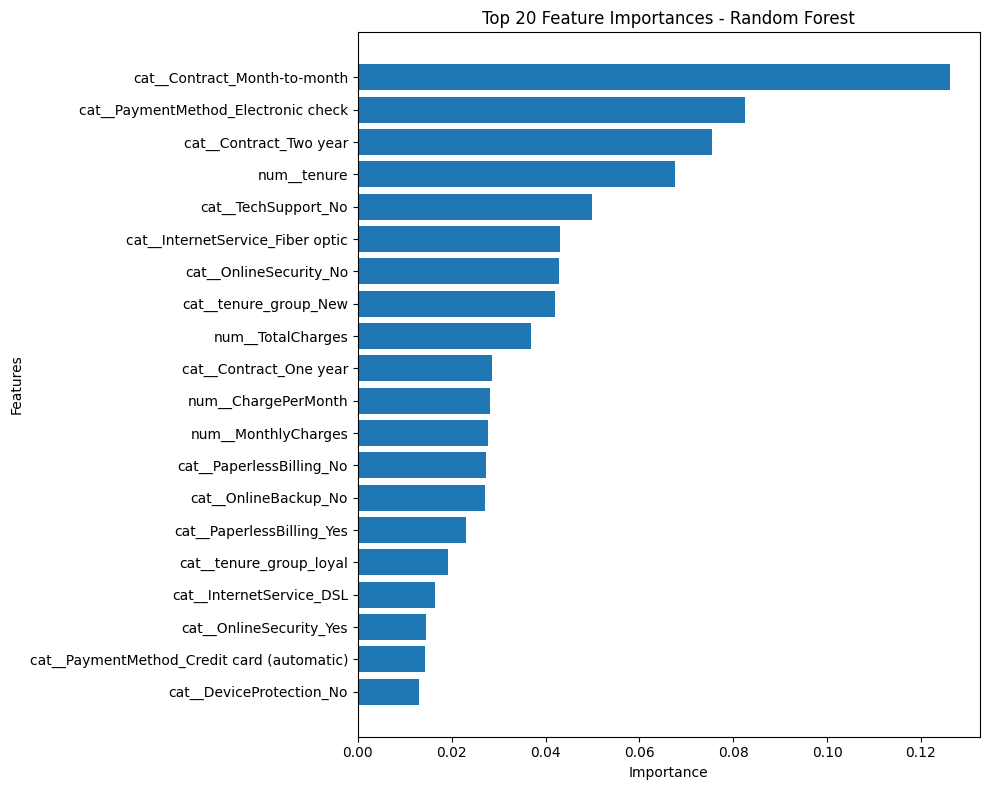

In [68]:
top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 20 Feature Importances - Random Forest")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [70]:
joblib.dump(pipeline_RF, 'churn_pipeline.pkl')

['churn_pipeline.pkl']